# Credit Card Default Prediction

## Data & Preprocessing (Role 1)

This notebook section contains Role 1 deliverables: data loading, cleaning, preprocessing decisions, preprocessing diagnostic plots, and engineered feature generation.

Problem framing and data-understanding narrative are report-only and are intentionally not repeated in this notebook section.

### Role 1 Objectives
- Build a reproducible data preprocessing pipeline.
- Document and justify data cleaning decisions with diagnostic evidence.
- Deliver a clean handoff artifact set to Role 2 for EDA-based feature selection and final preprocessing design.

In [3]:
import random
import subprocess
import sys

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print(f"Data source: ucimlrepo (id=350) - online only")

Data source: ucimlrepo (id=350) - online only


## 1) Data Source and Loading

In [4]:
# Fetch directly from UCI repository (online only)
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    print("Installing ucimlrepo...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"])
    from ucimlrepo import fetch_ucirepo

default_of_credit_card_clients = fetch_ucirepo(id=350)
X_uci = default_of_credit_card_clients.data.features.copy()
y_uci = default_of_credit_card_clients.data.targets.copy()

# Normalize target to a 1D series
if isinstance(y_uci, pd.DataFrame):
    if y_uci.shape[1] == 1:
        y_uci = y_uci.iloc[:, 0]
    else:
        y_uci = y_uci.squeeze()
y_uci = y_uci.rename("default payment next month")

df_raw = pd.concat([X_uci, y_uci], axis=1)
data_source = "ucimlrepo"

print("Loaded dataset from ucimlrepo.")

# Standardize column names across both schemas (X1..X23/Y vs readable names)
column_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "default payment next month",
    "default.payment.next.month": "default payment next month",
}

df_raw = df_raw.rename(columns=column_map)

print(f"Data source used: {data_source}")
print(f"Shape: {df_raw.shape}")
print("Columns:")
print(df_raw.columns.tolist())

df_raw.head()

Installing ucimlrepo...
Loaded dataset from ucimlrepo.
Data source used: ucimlrepo
Shape: (30000, 24)
Columns:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2) Data Quality Audit and Type Harmonization

In [5]:
target_candidates = [
    "default payment next month",
    "default.payment.next.month",
    "default_payment_next_month",
    "Y",
]

target_col = next((c for c in target_candidates if c in df_raw.columns), None)
if target_col is None:
    raise ValueError(f"Could not identify target column. Available columns: {df_raw.columns.tolist()}")

id_col = "ID" if "ID" in df_raw.columns else None

audit_df = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing_count": df_raw.isna().sum(),
        "missing_pct": (df_raw.isna().mean() * 100).round(2),
        "n_unique": df_raw.nunique(),
    }
).sort_index()

print(f"Target column: {target_col}")
print(f"ID column detected: {id_col}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print("Class distribution:")
print(df_raw[target_col].value_counts(normalize=True).rename("ratio").round(4))

audit_df

Target column: default payment next month
ID column detected: None
Duplicate rows: 35
Class distribution:
default payment next month
0    0.7788
1    0.2212
Name: ratio, dtype: float64


,dtype,missing_count,missing_pct,n_unique
AGE,int64,0,0.0,56
BILL_AMT1,int64,0,0.0,22723
BILL_AMT2,int64,0,0.0,22346
BILL_AMT3,int64,0,0.0,22026
BILL_AMT4,int64,0,0.0,21548
BILL_AMT5,int64,0,0.0,21010
BILL_AMT6,int64,0,0.0,20604
EDUCATION,int64,0,0.0,7
LIMIT_BAL,int64,0,0.0,81
MARRIAGE,int64,0,0.0,4


In [6]:
# Force PAY_* columns to share one common category space
pay_cols = [c for c in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] if c in df_raw.columns]

# Ensure categorical dtype first
for c in pay_cols:
    if not isinstance(df_raw[c].dtype, pd.CategoricalDtype):
        df_raw[c] = df_raw[c].astype("category")

# Build union of all observed categories across PAY columns
all_pay_categories = sorted(
    set().union(*[set(df_raw[c].cat.categories.tolist()) for c in pay_cols])
)

# Apply the same categories to every PAY column
for c in pay_cols:
    df_raw[c] = df_raw[c].cat.set_categories(all_pay_categories)

print("Unified PAY categories:")
print(all_pay_categories)

print("\nCategory count per PAY column:")
for c in pay_cols:
    print(f"{c}: {len(df_raw[c].cat.categories)}")

Unified PAY categories:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

Category count per PAY column:
PAY_0: 11
PAY_2: 11
PAY_3: 11
PAY_4: 11
PAY_5: 11
PAY_6: 11


In [7]:
df_raw.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 3) Preprocessing Diagnostics and Cleaning Decisions (Role 1)

This section uses preprocessing-focused diagnostics to justify category harmonization, invalid-category handling, deduplication, and recoding decisions.

These plots are Role 1 preprocessing evidence and are separate from Role 2 EDA plots.

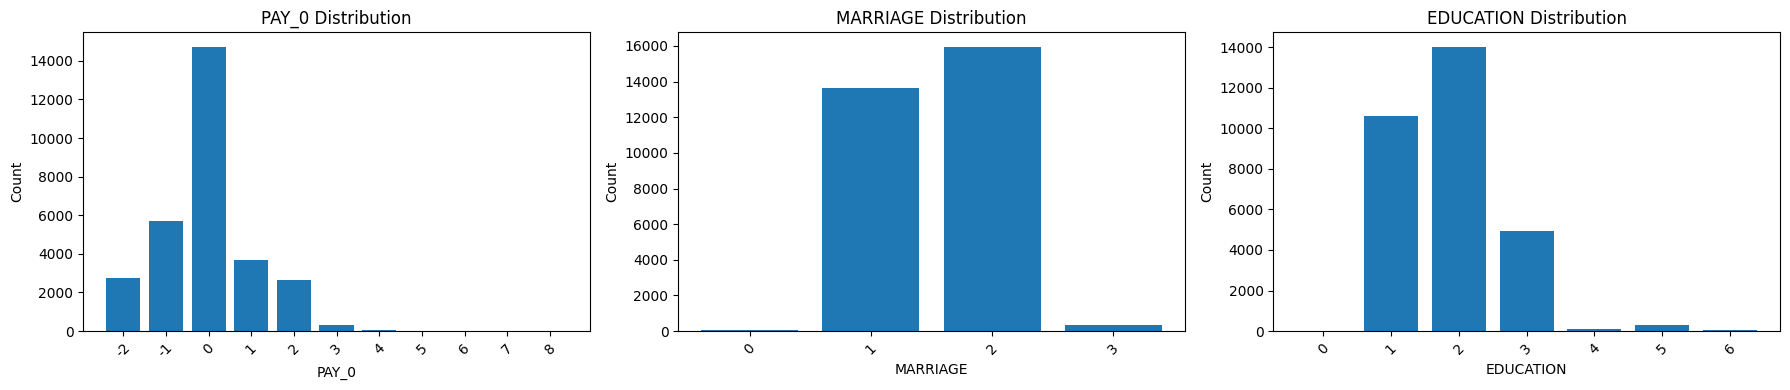

In [8]:
import matplotlib.pyplot as plt

plot_columns = ["PAY_0", "MARRIAGE", "EDUCATION"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, plot_columns):
    if col in df_raw.columns:
        counts = df_raw[col].value_counts(dropna=False).sort_index()
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title(f"{col} Distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_title(f"{col} not found")
        ax.axis("off")

plt.tight_layout()
plt.show()

Preprocessing interpretation:
- The raw distributions show categorical imbalance and uncommon codes that need controlled recoding.
- These counts justify semantic regrouping for `EDUCATION`, `MARRIAGE`, and repayment status fields.
- Keeping this diagnostic separate from EDA ensures it is used as cleaning evidence, not model insight evidence.

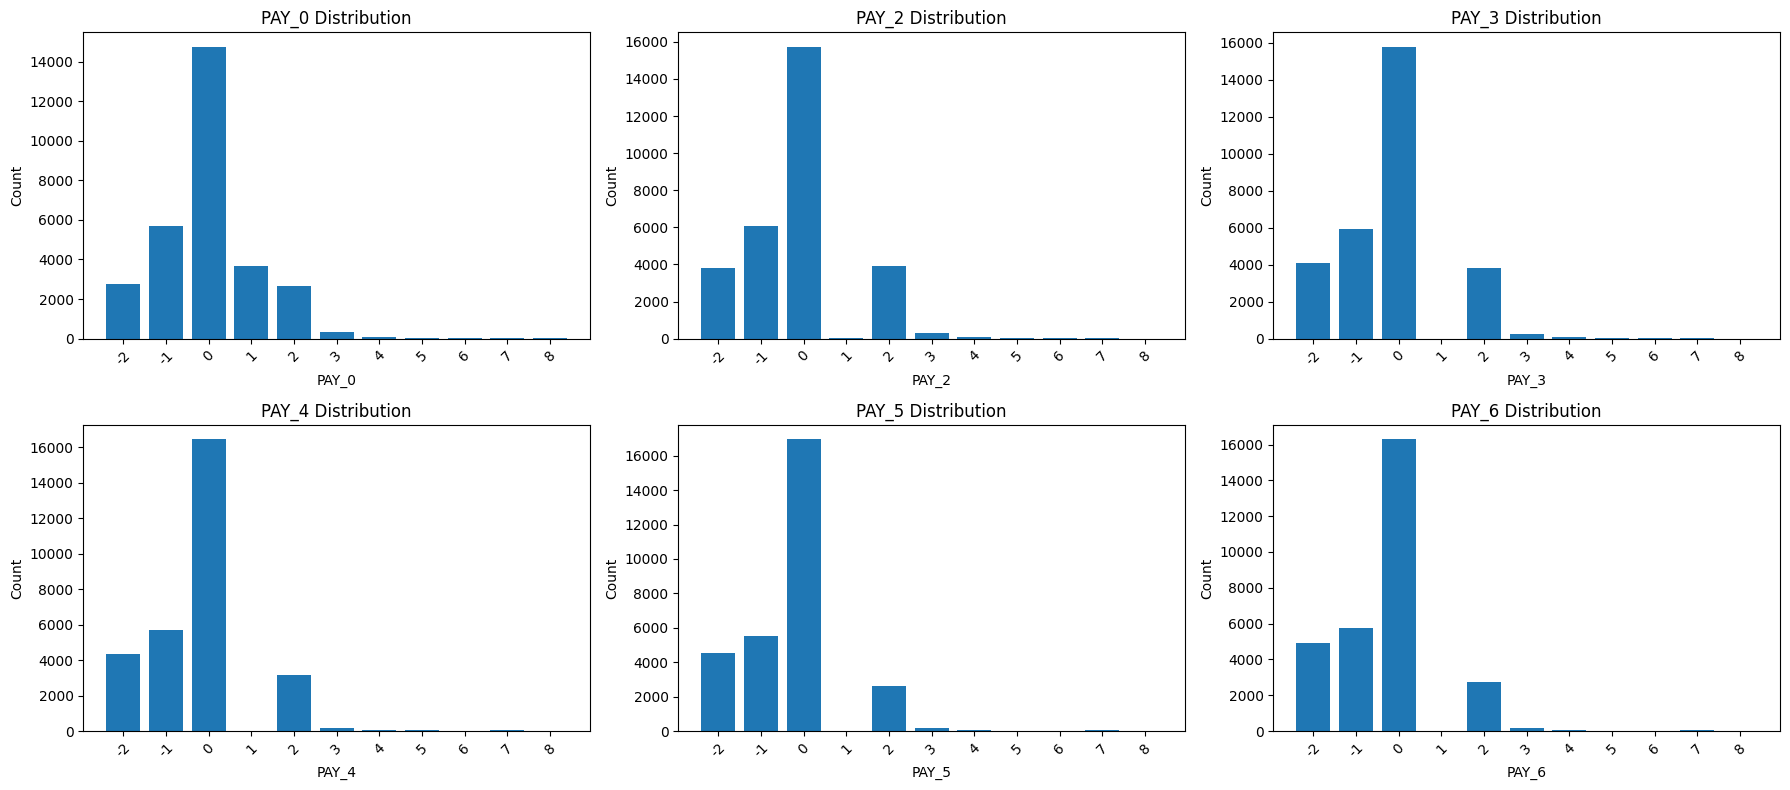

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

for ax, col in zip(axes, pay_cols):
    if col in df_raw.columns:
        counts = df_raw[col].value_counts(dropna=False).sort_index()
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title(f"{col} Distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_title(f"{col} not found")
        ax.axis("off")

plt.tight_layout()
plt.show()

Preprocessing interpretation:
- Repayment status columns have a shared but sparse category space, so category harmonization is required before downstream encoding.
- Rare repayment states are preserved but mapped to stable semantic labels to reduce ambiguity.
- This step supports consistent preprocessing behavior across all PAY columns.

In [10]:
for col in ["PAY_0", "PAY_2"]:
    print(f"\n{col} value counts:")
    print(df_raw[col].value_counts(dropna=False).sort_index())


PAY_0 value counts:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2 value counts:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64


In [11]:
# 5 people for each requested repayment-status value in PAY_0 and PAY_2
target_values = [-2, -1, 0]
cols = ["PAY_0", "PAY_2"]

samples = []
for col in cols:
    for val in target_values:
        subset = df_raw[df_raw[col] == val]
        n = min(5, len(subset))
        sampled = subset.sample(n=n, random_state=RANDOM_STATE).copy()
        sampled["matched_column"] = col
        sampled["matched_value"] = val
        samples.append(sampled)

result = pd.concat(samples, ignore_index=False)

display(result)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,matched_column,matched_value
4781,20000,2,3,1,30,-2,-2,-2,-2,-2,-1,18920,20030,21408,21974,22391,27189,1700,2000,1200,1000,12000,1000,0,PAY_0,-2
16736,200000,1,2,1,31,-2,-2,-2,-2,-2,-2,6926,1747,642,0,0,0,1747,642,0,0,0,500,0,PAY_0,-2
27322,360000,1,2,2,37,-2,-2,-2,-2,-2,-2,880,22311,-447,-6146,13461,0,22311,26,0,25461,0,0,0,PAY_0,-2
26192,200000,2,2,1,29,-2,-2,-2,-2,-2,-2,8350,14139,3580,6386,868,10415,14185,7425,6386,868,10647,4320,1,PAY_0,-2
6801,380000,1,1,1,53,-2,-2,-2,-2,-2,-2,360,360,360,720,360,360,360,360,720,0,360,360,0,PAY_0,-2
18107,420000,1,1,2,36,-1,-1,-1,2,2,2,9464,37856,31429,22483,16437,-2474,40146,23040,63,104,23,50212,0,PAY_0,-1
21640,100000,2,2,2,24,-1,-1,-2,-2,-1,-1,3587,660,6010,2789,2973,3611,660,6010,2789,2973,3611,11880,0,PAY_0,-1
21912,30000,2,2,2,22,-1,0,-1,-1,-1,-1,2293,3158,5547,3312,3145,3022,1009,5572,3321,3154,3031,3339,0,PAY_0,-1
8980,200000,1,1,2,29,-1,-1,-1,-1,-1,-1,170,3300,38526,-93,18681,12399,3318,42497,0,18774,12461,9526,0,PAY_0,-1
16780,210000,1,1,2,40,-1,-1,-1,-1,-1,-1,1535,2652,179,1326,1326,1326,2652,179,1326,1326,1326,4182,1,PAY_0,-1


Preprocessing interpretation:
- Sample-level inspection confirms that mapped repayment categories correspond to realistic account patterns.
- Manual spot checks reduce risk of incorrect remapping before engineered features are generated.
- This provides traceable evidence for preprocessing correctness in Role 1.

## 4) Cleaning, Recoding, Deduplication, and Feature Engineering

In this section, Role 1 applies approved recoding rules, removes invalid categories and duplicate rows, then generates the full engineered feature set.

Feature selection is intentionally deferred to Role 2, who will decide which engineered features to keep based on EDA insights.

In [12]:
rows_before = len(df_raw)

df_nodup = df_raw.drop_duplicates().copy()

rows_after = len(df_nodup)
dup_count = rows_before - rows_after

print(f"Duplicate rows found: {dup_count}")
print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")

# Build modeling features and target from the deduplicated frame
X = df_nodup.drop(columns=[target_col]).copy()
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

y = df_nodup[target_col].astype(int).copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Duplicate rows found: 35
Rows before: 30000
Rows after: 29965
X shape: (29965, 23)
y shape: (29965,)


In [13]:
# Remap repayment status columns to semantic categories
pay_semantic_map = {
    -2: "no_credit",
    -1: "paid_in_full",
    0: "revolving",
    1: "delay_1_month",
    2: "delay_2_months",
}

pay_semantic_categories = [
    "no_credit",
    "paid_in_full",
    "revolving",
    "delay_1_month",
    "delay_2_months",
    "delay_3_plus_months",
]

def map_pay_status(series: pd.Series) -> pd.Series:
    mapped = series.apply(
        lambda v: pay_semantic_map.get(v, "delay_3_plus_months" if pd.notna(v) and v >= 3 else np.nan)
    )
    return pd.Categorical(mapped, categories=pay_semantic_categories, ordered=True)

for c in pay_cols:
    if c in df_raw.columns:
        df_raw[c] = map_pay_status(df_raw[c])

if "df_nodup" in globals():
    for c in pay_cols:
        if c in df_nodup.columns:
            df_nodup[c] = map_pay_status(df_nodup[c])

if "X" in globals():
    for c in pay_cols:
        if c in X.columns:
            X[c] = map_pay_status(X[c])

print("Updated PAY column categories:")
for c in pay_cols:
    if c in df_raw.columns:
        print(f"{c}: {list(df_raw[c].cat.categories)}")

Updated PAY column categories:
PAY_0: ['no_credit', 'paid_in_full', 'revolving', 'delay_1_month', 'delay_2_months', 'delay_3_plus_months']
PAY_2: ['no_credit', 'paid_in_full', 'revolving', 'delay_1_month', 'delay_2_months', 'delay_3_plus_months']
PAY_3: ['no_credit', 'paid_in_full', 'revolving', 'delay_1_month', 'delay_2_months', 'delay_3_plus_months']
PAY_4: ['no_credit', 'paid_in_full', 'revolving', 'delay_1_month', 'delay_2_months', 'delay_3_plus_months']
PAY_5: ['no_credit', 'paid_in_full', 'revolving', 'delay_1_month', 'delay_2_months', 'delay_3_plus_months']
PAY_6: ['no_credit', 'paid_in_full', 'revolving', 'delay_1_month', 'delay_2_months', 'delay_3_plus_months']


In [14]:
education_map = {1: "graduate_school", 2: "university", 3: "high_school"}
marriage_map = {1: "married", 2: "single", 3: "others"}
gender_map = {1: "male", 2: "female"}

def recode_and_filter(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    before = len(out)

    out = out[(out["EDUCATION"] != 0) & (out["MARRIAGE"] != 0)].copy()

    out["EDUCATION"] = out["EDUCATION"].apply(lambda v: education_map.get(v, "others"))
    out["MARRIAGE"] = out["MARRIAGE"].apply(lambda v: marriage_map.get(v, "others"))
    out["SEX"] = out["SEX"].map(gender_map)

    out["EDUCATION"] = pd.Categorical(
        out["EDUCATION"],
        categories=["graduate_school", "university", "high_school", "others"],
        ordered=False,
    )
    out["MARRIAGE"] = pd.Categorical(
        out["MARRIAGE"],
        categories=["married", "single", "others"],
        ordered=False,
    )
    out["SEX"] = pd.Categorical(out["SEX"], categories=["male", "female"], ordered=False)

    print(f"Rows removed: {before - len(out)}")
    return out

df_raw = recode_and_filter(df_raw)
df_nodup = recode_and_filter(df_nodup)
X = df_nodup.drop(columns=[target_col]).copy()
y = df_nodup[target_col].astype(int).copy()

print("Updated EDUCATION values:", X["EDUCATION"].unique().tolist())
print("Updated MARRIAGE values:", X["MARRIAGE"].unique().tolist())
print("Updated SEX values:", X["SEX"].unique().tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Rows removed: 68
Rows removed: 68
Updated EDUCATION values: ['university', 'graduate_school', 'high_school', 'others']
Updated MARRIAGE values: ['married', 'single', 'others']
Updated SEX values: ['female', 'male']
X shape: (29897, 23)
y shape: (29897,)


In [15]:
bill_cols = [c for c in ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"] if c in X.columns]
pay_cols_amt = [c for c in ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"] if c in X.columns]

def safe_div(numer, denom):
    denom = denom.astype(float)
    numer = numer.astype(float)
    return np.where(denom != 0, numer / denom, 0.0)

def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    # Aggregate bill/payment features
    out["TOTAL_BILL_AMT"] = out[bill_cols].sum(axis=1)
    out["TOTAL_PAY_AMT"] = out[pay_cols_amt].sum(axis=1)
    out["NET_BILL_AFTER_PAY"] = out["TOTAL_BILL_AMT"] - out["TOTAL_PAY_AMT"]

    # Bill behavior
    out["BILL_AVG"] = out[bill_cols].mean(axis=1)
    out["BILL_VAR"] = out[bill_cols].var(axis=1)
    out["BILL_TREND_SEP_TO_APR"] = out["BILL_AMT1"] - out["BILL_AMT6"]

    # Debt growth / decline
    out["IS_DEBT_GROWING"] = (out["BILL_AMT1"] - out["BILL_AMT2"] > 0).astype("int8")

    # Monthly ratios
    for i in range(1, 7):
        bill_col = f"BILL_AMT{i}"
        pay_col = f"PAY_AMT{i}"
        out[f"PAY_TO_BILL_RATIO_{i}"] = safe_div(out[pay_col], out[bill_col])
        out[f"UTILIZATION_{i}"] = safe_div(out[bill_col], out["LIMIT_BAL"])

    # Aggregate ratios
    out["AVG_PAY_TO_BILL_RATIO"] = out[[f"PAY_TO_BILL_RATIO_{i}" for i in range(1, 7)]].mean(axis=1)
    out["AVG_UTILIZATION"] = out[[f"UTILIZATION_{i}" for i in range(1, 7)]].mean(axis=1)
    out["MAX_UTILIZATION"] = out[[f"UTILIZATION_{i}" for i in range(1, 7)]].max(axis=1)

    return out

for name in ["df_raw", "df_nodup", "X"]:
    if name in globals():
        globals()[name] = add_engineered_features(globals()[name])

print("Engineered features added.")
print([c for c in X.columns if c in [
    "TOTAL_BILL_AMT", "TOTAL_PAY_AMT", "NET_BILL_AFTER_PAY",
    "BILL_AVG", "BILL_VAR",
    "BILL_TREND_SEP_TO_APR", "IS_DEBT_GROWING",
    "AVG_PAY_TO_BILL_RATIO", "AVG_UTILIZATION", "MAX_UTILIZATION"
]])


Engineered features added.
['TOTAL_BILL_AMT', 'TOTAL_PAY_AMT', 'NET_BILL_AFTER_PAY', 'BILL_AVG', 'BILL_VAR', 'BILL_TREND_SEP_TO_APR', 'IS_DEBT_GROWING', 'AVG_PAY_TO_BILL_RATIO', 'AVG_UTILIZATION', 'MAX_UTILIZATION']


In [16]:

# 1. Force pandas to show all rows in the output
with pd.option_context('display.max_rows', None):

    # 2. Build a summary table
    summary = pd.DataFrame({
        'Data Type': X.dtypes,
        'Unique Values': X.nunique(),
        'Missing Values': X.isnull().sum()
    })

    display(summary)

,Data Type,Unique Values,Missing Values
LIMIT_BAL,int64,81,0
SEX,category,2,0
EDUCATION,category,4,0
MARRIAGE,category,3,0
AGE,int64,56,0
PAY_0,category,6,0
PAY_2,category,6,0
PAY_3,category,6,0
PAY_4,category,6,0
PAY_5,category,5,0


## 5) Split Strategy Specification (Markdown Only)

This is a handoff requirement for Role 2/Role 3 implementation and is not executed in Role 1.

Required split policy:
- Use stratified 80/20 train/test split.
- Use a fixed random seed (`RANDOM_STATE`) for reproducibility.
- Perform cross-validation only on the training split.
- Prevent leakage by fitting all preprocessing transformers on training data only and reusing the fitted objects on validation/test data.

## 6) Transformer Specification (Markdown Only)

This is a Role 2 implementation specification and is not executed in Role 1.

Required transformer behavior:
- Input: final feature matrix `X` after Role 2 feature selection and a list of categorical columns.
- Binary categorical columns: encode to one output column (drop one category).
- Categorical columns with more than two levels: full one-hot encoding.
- Numeric/integer columns: keep and scale/normalize.
- Fit only on training data and reuse the same fitted transformer for validation/test data.
- Output artifacts: fitted transformer, transformed train matrix, transformed test matrix with consistent column order.

## 7) Role 1 Output Contract and Role 2 Checklist

### Role 1 Output Contract (Produced in this notebook)
- `df_nodup`: cleaned and deduplicated dataset after recoding/filtering.
- `X`: full candidate feature matrix after engineered features are added.
- `y`: target series aligned with `X`.
- Mapping dictionaries and category definitions: `pay_semantic_map`, `pay_semantic_categories`, `education_map`, `marriage_map`, `gender_map`.
- Data-quality and preprocessing diagnostics: `audit_df`, category distributions, and validation prints.

### Role 2 Checklist (Next Owner)
- Keep Role 1 preprocessing diagnostic plots separate from Role 2 EDA plots.
- Run EDA and use insights to select final kept features from `X`.
- Implement the split strategy from Section 5 (no leakage).
- Implement the transformer from Section 6 and produce modeling-ready transformed data for Role 3.

### Submission Traceability Note
Role 1 contribution in this notebook: data loading, cleaning, recoding, deduplication, preprocessing diagnostics, and full engineered feature generation.

# Role 2: Exploratory Data Analysis & Feature Selection & Visualization
In this section, we analyze the relationship between the engineered features provided by Role 1 and the target variable.


## 2.1 Final Feature Set Inspection
In this step, we generate a statistical summary of the engineered feature matrix **(X)**. This allows us to inspect the data ranges and identify features with low variance. Note that variance is only calculated for numerical features to identify constants that might not contribute to the model's predictive power.

In [22]:
# Detailed statistics for all features
print("Statistical Summary of X:")
display(X.describe(include='all')) # include='all' covers both numeric and categorical

# Checking for any constant features (low variance) - Numeric Only
print("\nFeature Variance Check (Numeric Features):")
# We use select_dtypes to avoid the TypeError with categorical columns
numeric_variance = X.select_dtypes(include='number').var().sort_values()
print(numeric_variance.head())

Statistical Summary of X:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TOTAL_BILL_AMT,TOTAL_PAY_AMT,NET_BILL_AFTER_PAY,BILL_AVG,BILL_VAR,BILL_TREND_SEP_TO_APR,IS_DEBT_GROWING,PAY_TO_BILL_RATIO_1,UTILIZATION_1,PAY_TO_BILL_RATIO_2,UTILIZATION_2,PAY_TO_BILL_RATIO_3,UTILIZATION_3,PAY_TO_BILL_RATIO_4,UTILIZATION_4,PAY_TO_BILL_RATIO_5,UTILIZATION_5,PAY_TO_BILL_RATIO_6,UTILIZATION_6,AVG_PAY_TO_BILL_RATIO,AVG_UTILIZATION,MAX_UTILIZATION
count,29897.000000,29897,29897,29897,29897.000000,29897,29897,29897,29897,29897,29897,29897.000000,29897.000000,2.989700e+04,29897.000000,29897.000000,29897.000000,29897.00000,2.989700e+04,29897.000000,29897.000000,29897.00000,29897.000000,2.989700e+04,2.989700e+04,2.989700e+04,29897.000000,2.989700e+04,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000,29897.000000
unique,NaN,2,4,3,NaN,6,6,6,6,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,female,university,single,NaN,revolving,revolving,revolving,revolving,revolving,revolving,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,18045,14013,15935,NaN,14713,15704,15743,16433,16919,16264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,167481.007459,NaN,NaN,NaN,35.482189,NaN,NaN,NaN,NaN,NaN,NaN,51357.287420,49300.358698,4.713199e+04,43371.262568,40414.654514,38972.686858,5666.13202,5.930339e+03,5232.180319,4835.738067,4810.79814,5227.923002,2.705482e+05,3.170311e+04,2.388451e+05,45091.373443,5.595981e+08,12384.600562,0.438974,-2.238324,0.424686,-1.705768,0.411991,-6.229242,0.393063,-1.428822,0.360275,-0.744707,0.333856,-0.593745,0.319298,-2.156768,0.373862,0.495982
std,129833.803736,NaN,NaN,NaN,9.220605,NaN,NaN,NaN,NaN,NaN,NaN,73716.802341,71252.219289,6.942675e+04,64406.561876,60865.505156,59621.313739,16564.45998,2.307283e+04,17630.203366,15689.181284,15302.15975,17804.826883,3.799787e+05,6.089928e+04,3.635798e+05,63329.778509,3.453671e+09,43982.608379,0.496270,231.515900,0.411538,104.646531,0.404665,603.061997,0.396572,145.801340,0.368795,65.941444,0.350660,80.682746,0.345420,114.698469,0.351946,0.433076
min,10000.000000,NaN,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.00000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,-3.362590e+05,0.000000e+00,-2.671514e+06,-56043.166667,0.000000e+00,-428791.000000,0.000000,-35436.000000,-0.619892,-10259.500000,-1.395540,-82150.000000,-1.025100,-17266.666667,-1.374500,-7483.947368,-0.876743,-11349.571429,-1.509530,-13727.477930,-0.232590,-0.100000
25%,50000.000000,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,3608.000000,3031.000000,2.735000e+03,2376.000000,1799.000000,1271.000000,1000.00000,8.500000e+02,392.000000,300.000000,264.00000,138.000000,2.914300e+04,6.700000e+03,4.684000e+03,4857.166667,2.420880e+06,-2976.000000,0.000000,0.031817,0.022360,0.026793,0.018590,0.012790,0.016414,0.000166,0.014522,0.000000,0.011307,0.000000,0.008000,0.037650,0.030367,0.071288
50%,140000.000000,NaN,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,22479.000000,21351.000000,2.016500e+04,19100.000000,18152.000000,17144.000000,2103.00000,2.011000e+03,1807.000000,1500.000000,1500.00000,1500.000000,1.268120e+05,1.440700e+04,1.024500e+05,21135.333333,2.110831e+07,938.000000,0.000000,0.052672,0.316429,0.050916,0.298060,0.041744,0.275294,0.037970,0.243500,0.040045,0.213944,0.039552,0.186600,0.065208,0.286231,0.433138
75%,240000.000000,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN,67417.000000,64165.000000,6.0


Feature Variance Check (Numeric Features):
UTILIZATION_6      0.119315
UTILIZATION_5      0.122962
AVG_UTILIZATION    0.123866
UTILIZATION_4      0.136009
UTILIZATION_3      0.157270
dtype: float64



> **Interpretation:**
> The descriptive statistics for the final feature matrix **(X)** highlight several key characteristics:
> * **Scale Disparity:** Features like **'LIMIT_BAL'** and **'BILL_AMT'** show very high mean and standard deviation compared to features like **'AGE'** or **'PAY_0'**. This confirms the necessity of applying **StandardScaler** to normalize the data.
> * **Variance Check:** The variance check confirms that none of the numeric features have zero variance (constant values), meaning all current features carry some level of information.
> * **Class Imbalance:** Based on the target analysis, only about **22%** of clients defaulted, which means we must focus on **F1-score** rather than accuracy to judge our model's success.


## 2.2 Target Class Distribution
We begin by visualizing the distribution of the target variable, **'default payment next month'**, to understand the balance between classes. This is critical for selecting the right evaluation metrics later.

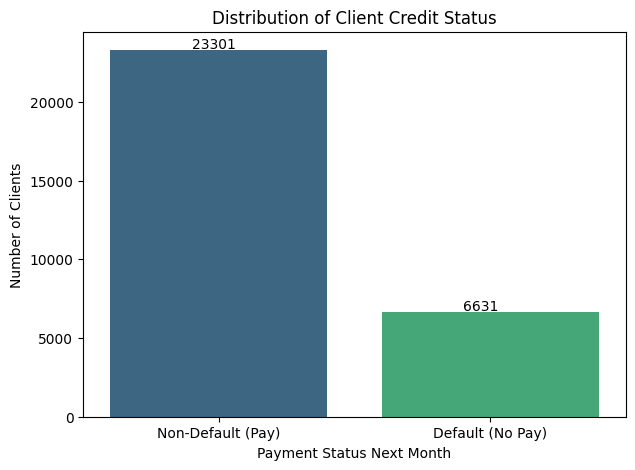

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')

plt.figure(figsize=(7,5))


ax = sns.countplot(
    x='default payment next month',
    data=df_raw,
    hue='default payment next month',
    palette='viridis',
    legend=False
)


ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Default (Pay)', 'Default (No Pay)'])

plt.title('Distribution of Client Credit Status')
plt.xlabel('Payment Status Next Month')
plt.ylabel('Number of Clients')


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+100))

plt.show()

> **Interpretation:**
> The visualization has been updated to clearly distinguish between **Non-Default** (clients expected to pay) and **Default** (clients at risk). The count labels on top of each bar indicate that we have over **23,000** reliable clients versus approximately **6,600** potential defaulters. This clear labeling helps in identifying the class imbalance problem at a glance, justifying the need for specialized sampling or evaluation techniques in the modeling phase.

### 2.3 Age Distribution and Credit Risk
In this section, we use a Kernel Density Estimate (KDE) plot to explore how age influences the likelihood of default.

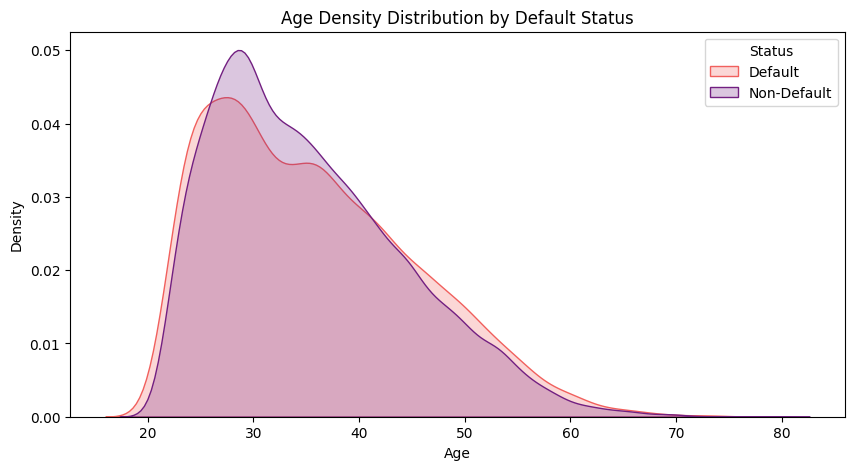

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

plt.figure(figsize=(10,5))

# Using hue and legend for a clean KDE plot
sns.kdeplot(
    data=df_raw,
    x='AGE',
    hue='default payment next month',
    fill=True,
    common_norm=False,
    palette='magma'
)

plt.title('Age Density Distribution by Default Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Status', labels=['Default', 'Non-Default'])

plt.show()

> **Interpretation:**
> The Kernel Density Estimate (KDE) plot reveals that younger clients, particularly those in the **20-30 age bracket**, show a higher density of defaults compared to older groups. As the age increases beyond 40, the distribution of defaults tends to stabilize and decrease relative to the non-default class. This indicates that **'AGE'** carries valuable predictive information regarding credit risk.

## 2.4 Multicollinearity Analysis
We generate a heatmap of the correlation matrix for numerical features to identify highly correlated predictors.

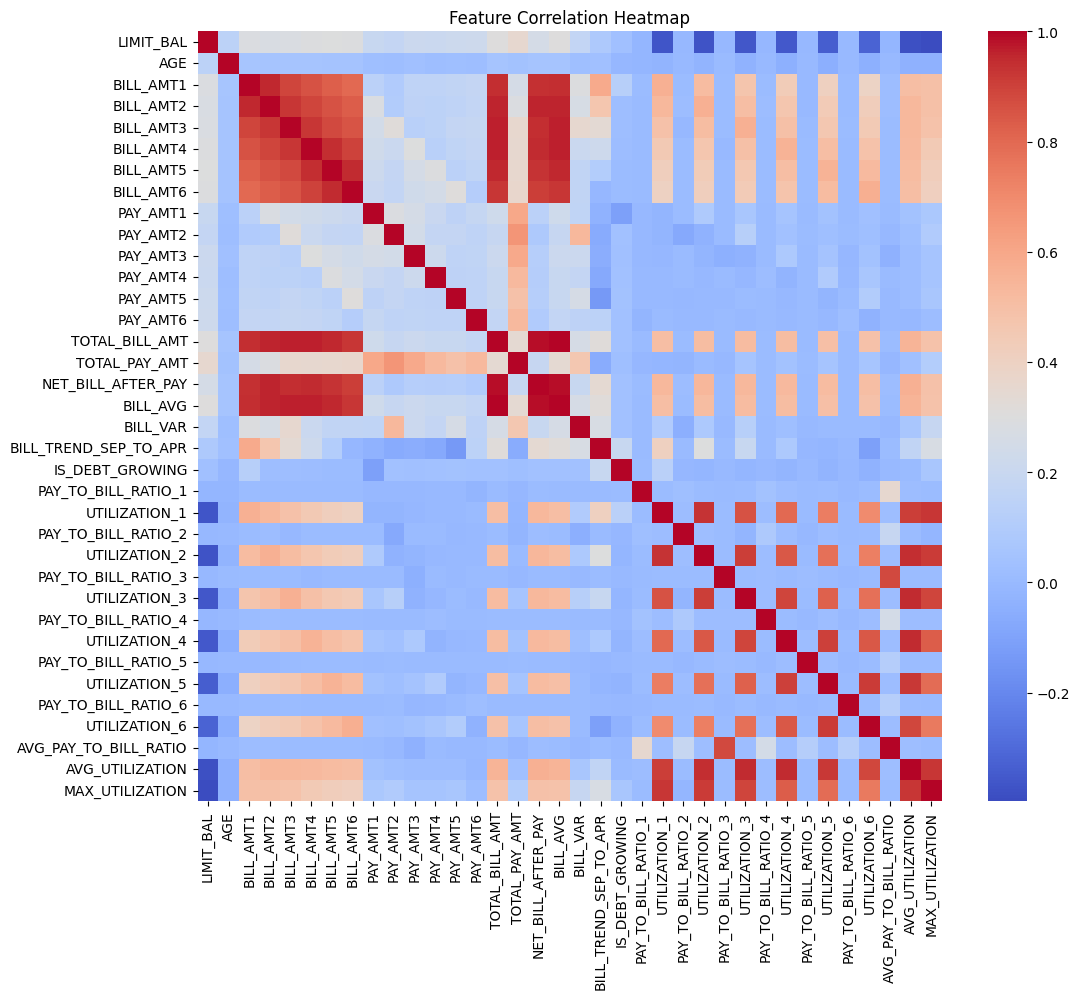

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

plt.figure(figsize=(12,10))

# Selecting only numeric columns to avoid TypeErrors
numeric_df = X.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')

plt.title('Feature Correlation Heatmap')
plt.show()

> **Interpretation:**
> The heatmap highlights strong multicollinearity among the billing features (**BILL_AMT1** to **BILL_AMT6**). While these features are important, we must be aware of this redundancy during feature selection to prevent overfitting and ensure the stability of models like Logistic Regression.

## 2.5 Feature Selection Rationale
Based on the **Feature Correlation Heatmap**, we have identified significant **Multicollinearity**—where multiple features provide redundant information. To optimize the model's performance and prevent overfitting, we will refine our feature set as follows:

* **Redundant Billing Data:** `BILL_AMT2` through `BILL_AMT6` show a near-perfect correlation (>$0.90$). We will retain `BILL_AMT1` and the engineered `BILL_AVG`, while dropping the rest.
* **Utilization Redundancy:** Similar to billing, the `UTILIZATION` 2-6 series is highly redundant. We will keep `AVG_UTILIZATION` and `MAX_UTILIZATION`.
* **Identifier Removal:** The `ID` column is dropped as it carries no predictive power.

**Outcome:** This reduction simplifies the model, reduces noise, and ensures that the training phase (Role 3) focuses on the most impactful, independent predictors.

In [32]:
import pandas as pd

# List of redundant features to drop based on Heatmap and domain analysis
features_to_remove = [
    'ID',
    'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'UTILIZATION_2', 'UTILIZATION_3', 'UTILIZATION_4', 'UTILIZATION_5', 'UTILIZATION_6'
]

# Dropping the features from the dataset (X)
# We use a list comprehension to ensure we only drop columns that exist
X_selected = X.drop(columns=[col for col in features_to_remove if col in X.columns])

print("Feature Selection Summary:")
print(f"-> Removed {len(features_to_remove)} redundant/non-predictive features.")
print(f"-> Final feature count for modeling: {X_selected.shape[1]}")
print(f"-> Remaining features: {list(X_selected.columns)}")

Feature Selection Summary:
-> Removed 11 redundant/non-predictive features.
-> Final feature count for modeling: 35
-> Remaining features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TOTAL_BILL_AMT', 'TOTAL_PAY_AMT', 'NET_BILL_AFTER_PAY', 'BILL_AVG', 'BILL_VAR', 'BILL_TREND_SEP_TO_APR', 'IS_DEBT_GROWING', 'PAY_TO_BILL_RATIO_1', 'UTILIZATION_1', 'PAY_TO_BILL_RATIO_2', 'PAY_TO_BILL_RATIO_3', 'PAY_TO_BILL_RATIO_4', 'PAY_TO_BILL_RATIO_5', 'PAY_TO_BILL_RATIO_6', 'AVG_PAY_TO_BILL_RATIO', 'AVG_UTILIZATION', 'MAX_UTILIZATION']


## 2.6 Recent Repayment Behavior Analysis
Analyzing the most recent repayment status (PAY_0) to verify its strength as a predictor.

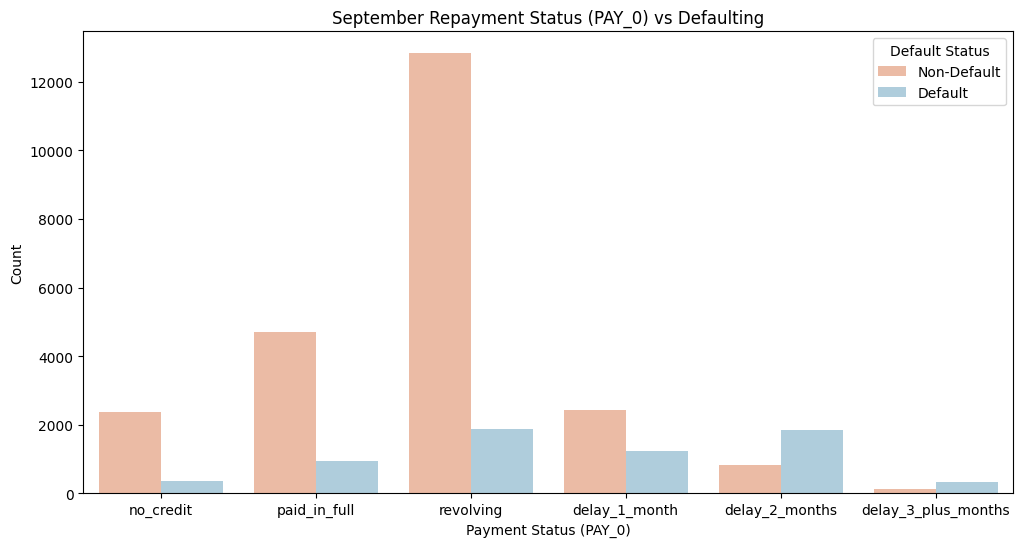

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_raw,
    x='PAY_0',
    hue='default payment next month',
    palette='RdBu'
)

plt.title('September Repayment Status (PAY_0) vs Defaulting')
plt.xlabel('Payment Status (PAY_0)')
plt.ylabel('Count')
plt.legend(title='Default Status', labels=['Non-Default', 'Default'])

plt.show()

> **Interpretation:**
> Analyzing **'PAY_0'** provides the strongest behavioral insight. There is a clear threshold: clients with a payment delay of **two months or more (PAY_0 ≥ 2)** show a disproportionately high frequency of defaulting. This makes recent payment history the most critical predictor in the dataset.

## 2.7  Split Strategy (No Leakage)
We split the data into training and testing sets **before** applying any transformations. This ensures that the statistics of the test set remain unknown to the model during training, preventing data leakage.

In [35]:
from sklearn.model_selection import train_test_split

# Splitting the data: 80% Train, 20% Test
# We use 'stratify=y' to maintain the class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (23917, 35)
Testing set size: (5980, 35)


## 2.8  Data Transformation (The Transformer)
To ensure optimal performance for linear models and distance-based algorithms, we apply **StandardScaler**. The scaler is fitted only on the training data and then applied to both the training and testing sets.

In [36]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize the scaler
scaler = StandardScaler()

# Select only numeric features for scaling
numeric_cols = X_train.select_dtypes(include='number').columns

# Fit on training data and transform both
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Prepare final DataFrames for Role 3
X_train_final = X_train_scaled
X_test_final = X_test_scaled

print("Data transformation complete. Final datasets (X_train_final, X_test_final) are ready for Role 3.")

Data transformation complete. Final datasets (X_train_final, X_test_final) are ready for Role 3.


### 2.9 Role 2 Summary & Handover Notes

In this stage (**Data Inspection & Preprocessing**), the following tasks were completed to prepare the dataset for model training:

1.  **Exploratory Data Analysis (EDA):**
    * **Statistical Summary:** Analyzed feature distributions and confirmed the necessity of scaling due to varying ranges (e.g., `LIMIT_BAL` vs. `PAY` status).
    * **Class Imbalance:** Identified a **22.1% default rate**, establishing the need for **Stratified Splitting** and focus on **Recall/F1-Score** metrics.
    * **Age Trends:** Observed higher default density in the **20-30 age group**, confirming `AGE` as a significant predictor.

2.  **Feature Selection & Rationale:**
    * **Multicollinearity Mitigation:** Based on the Heatmap, we dropped redundant billing (`BILL_AMT2-6`) and utilization (`UTILIZATION_2-6`) features to prevent overfitting.
    * **Redundancy Clean-up:** Removed the `ID` column as it lacks predictive value.

3.  **Preprocessing & Transformation:**
    * **Split Strategy:** Executed an **80/20 Stratified Split** (`random_state=42`) to maintain class proportions and ensure reproducible results.
    * **Feature Scaling:** Applied **StandardScaler** to all numerical features. The scaler was fitted strictly on the **Training Set** to prevent **Data Leakage**, then applied to the Test Set.

**Final Status:** The processed datasets (`X_train_scaled`, `X_test_scaled`) are now cleaned, scaled, and balanced for **Role 3** to proceed with Model Selection and Hyperparameter Tuning.